# Setup of pandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("Data/Processed/south_america_cleaned.csv")

df.head()

/Users/michellethomas/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


,HS Code,Commodity Name,Year,Month,Country,Nominal Value,Annual Inflation Rate,CPI,Real Value,Category Type
0,2504,Natural Graphite,2021,NaN,Argentina,5750,4.70,124.2543,4.627606e+03,Ore / Raw
1,2504,Natural Graphite,2015,NaN,Brazil,9941921,0.12,108.6937,9.146732e+06,Ore / Raw
2,2504,Natural Graphite,2016,NaN,Brazil,7426485,1.26,110.0632,6.747473e+06,Ore / Raw
3,2504,Natural Graphite,2017,NaN,Brazil,7601671,2.13,112.4076,6.762595e+06,Ore / Raw
4,2504,Natural Graphite,2018,NaN,Brazil,6469010,2.44,115.1503,5.617884e+06,Ore / Raw


# Commodity Level Analysis

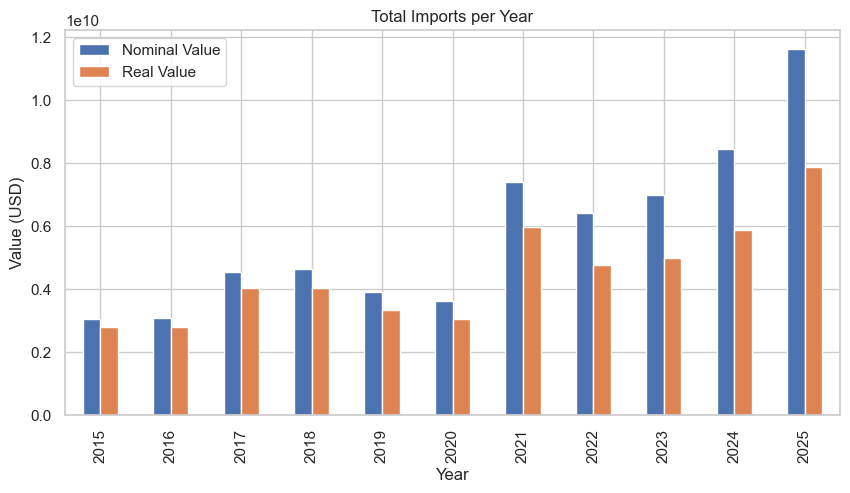

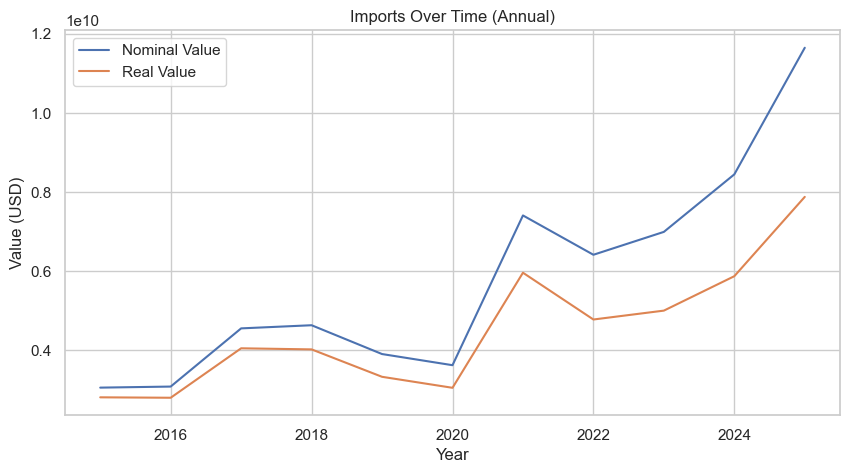

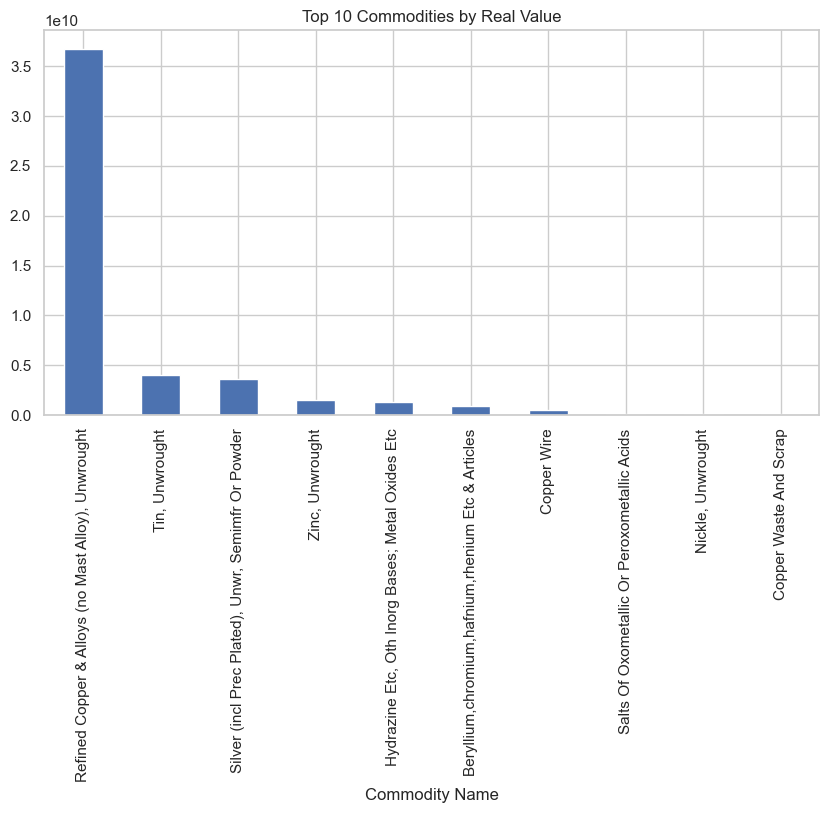

Commodity Name
Refined Copper & Alloys (no Mast Alloy), Unwrought    74.077348
Tin, Unwrought                                         8.207392
Silver (incl Prec Plated), Unwr, Semimfr Or Powder     7.427968
Zinc, Unwrought                                        3.070416
Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc       2.639282
Name: Real Value, dtype: float64
Combined Share: 95.42%


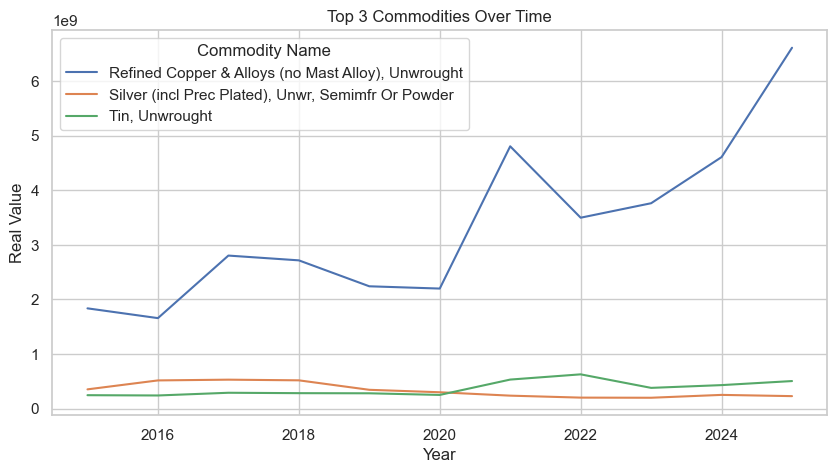

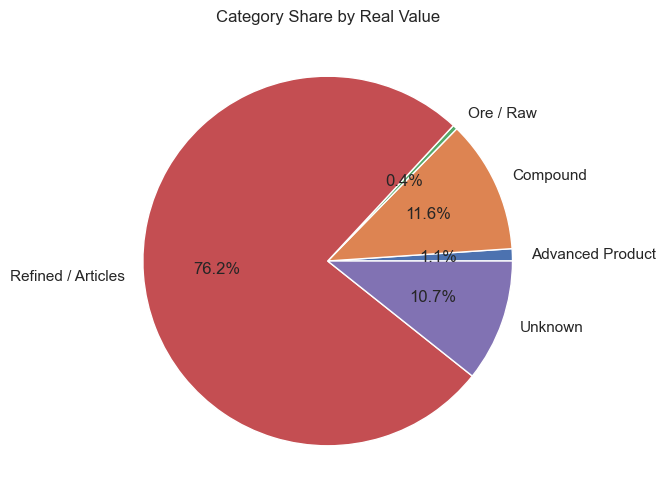

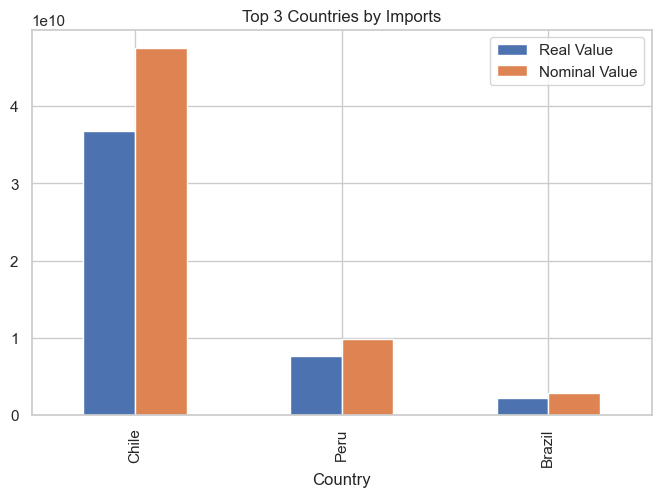

Country
Chile     74.141881
Peru      15.321242
Brazil     4.519024
Name: Real Value, dtype: float64
Combined Share: 93.98%


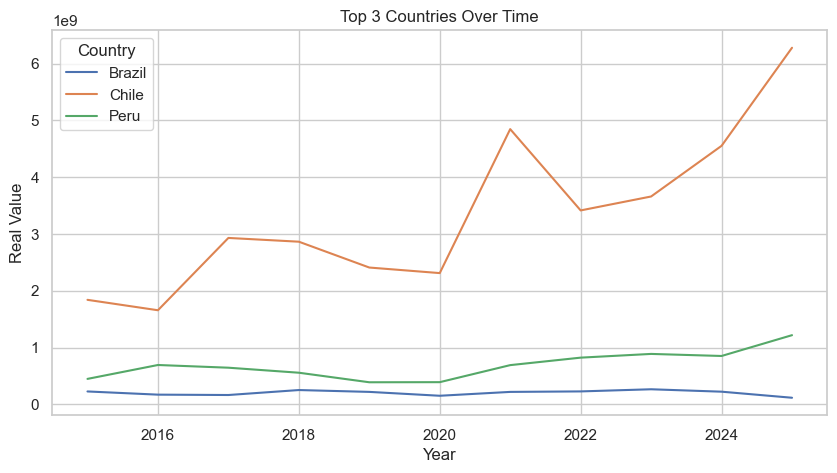

,Country,Commodity Name,Real Value
21,Brazil,"Tin, Unwrought",5.844569e+08
0,Brazil,"Beryllium,chromium,hafnium,rhenium Etc & Articles",5.406339e+08
6,Brazil,"Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc",5.189815e+08
31,Chile,"Refined Copper & Alloys (no Mast Alloy), Unwro...",3.403365e+10
33,Chile,"Silver (incl Prec Plated), Unwr, Semimfr Or Po...",1.388500e+09
29,Chile,"Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc",6.618159e+08
43,Peru,"Refined Copper & Alloys (no Mast Alloy), Unwro...",2.583577e+09
46,Peru,"Tin, Unwrought",1.962052e+09
49,Peru,"Zinc, Unwrought",1.340261e+09


In [3]:
## Bar Plot — Total Imports Per Year
yearly = df.groupby("Year")[["Nominal Value", "Real Value"]].sum()

yearly.plot(kind="bar", figsize=(10,5))
plt.title("Total Imports per Year")
plt.ylabel("Value (USD)")
plt.show()


##Yearly Trend (Line Plot)
yearly.plot(figsize=(10,5))
plt.title("Imports Over Time (Annual)")
plt.ylabel("Value (USD)")
plt.xlabel("Year")
plt.show()


##Top 10 Commodities (Real Value)
top10 = (
    df.groupby("Commodity Name")["Real Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Commodities by Real Value")
plt.show()


## % Share of Top 5 Commodities
total_real = df["Real Value"].sum()

top5 = top10.head(5)
percent_share = (top5 / total_real) * 100

print(percent_share)
print(f"Combined Share: {percent_share.sum():.2f}%")


##Time Series — Top 3 Commodities (Year-Based)
top3_names = top10.head(3).index

top3_df = df[df["Commodity Name"].isin(top3_names)]

ts = top3_df.groupby(["Year", "Commodity Name"])["Real Value"].sum().unstack()

ts.plot(figsize=(10,5))
plt.title("Top 3 Commodities Over Time")
plt.ylabel("Real Value")
plt.show()


##Category Type Distribution (Pie Chart)
category = df.groupby("Category Type")["Real Value"].sum()

category.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Category Share by Real Value")
plt.ylabel("")
plt.show()


##Top 3 Countries (Bar Plot)
top_countries = (
    df.groupby("Country")[["Real Value", "Nominal Value"]]
    .sum()
    .sort_values(by="Real Value", ascending=False)
    .head(3)
)

top_countries.plot(kind="bar", figsize=(8,5))
plt.title("Top 3 Countries by Imports")
plt.show()


## % Share of Top 3 Countries
total_real = df["Real Value"].sum()

country_share = (top_countries["Real Value"] / total_real) * 100

print(country_share)
print(f"Combined Share: {country_share.sum():.2f}%")


##Time Series — Top 3 Countries (Year-Based)
top3_country_names = top_countries.index

country_ts = (
    df[df["Country"].isin(top3_country_names)]
    .groupby(["Year", "Country"])["Real Value"]
    .sum()
    .unstack()
)

country_ts.plot(figsize=(10,5))
plt.title("Top 3 Countries Over Time")
plt.ylabel("Real Value")
plt.show()


##Top Commodities per Top Countries
subset = df[df["Country"].isin(top3_country_names)]

top_country_commodities = (
    subset.groupby(["Country", "Commodity Name"])["Real Value"]
    .sum()
    .reset_index()
)

top_country_commodities = top_country_commodities.sort_values(
    ["Country", "Real Value"], ascending=[True, False]
)

top_country_commodities.groupby("Country").head(3)


##